In [3]:
# Importing necessary libraries.
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Parameter Estimation

### Sampling and Comparision

In [18]:
# This Functions calculates the MLE estimates of mean and variance and the returns random samples from the generated distribution.
def MLE_sampling(k , num_samples = 900 , dim = 28*28 , zero_bias = 0):
    
    # Calculating the Sample Mean. 
    MLE_mean = np.zeros((dim , 1))
    for i in range(1 , num_samples + 1):
        path = 'MNIST_data/' + str(k) + '/' + str(i) + '.png'
        MLE_mean += mpimg.imread(path).reshape(-1,1) 

    MLE_mean = MLE_mean/num_samples

    # Calculating the Sample Variance.
    MLE_var = np.zeros((dim , dim))

    for i in range(1 , num_samples + 1):
        path = 'MNIST_data/' + str(k) + '/' + str(i) + '.png'
        img = mpimg.imread(path).reshape(-1,1)
        MLE_var += (img - MLE_mean)@((img - MLE_mean).T)

    MLE_var = MLE_var/(num_samples)

    # Take the unbiased version if zero bias is set to one.
    if zero_bias == 1 :
        MLE_var * (num_samples) / (num_samples - 1)
    
    # Sampling the images with multivariate gaussian with the calculated mean and variance.
    imgs = np.random.multivariate_normal(MLE_mean.reshape(784,) , MLE_var , 10) 

    # Plotting the images.
    fig, axes = plt.subplots(2,5, figsize=(8, 3))


    axes = axes.ravel()

    for i in range(len(imgs)):
        axes[i].imshow(imgs[i].reshape(28,28) , cmap = 'gray')
        axes[i].set_title(f"Image {i+1}")
        axes[i].axis("off")   

    plt.tight_layout()
    plt.show()
    
    return 


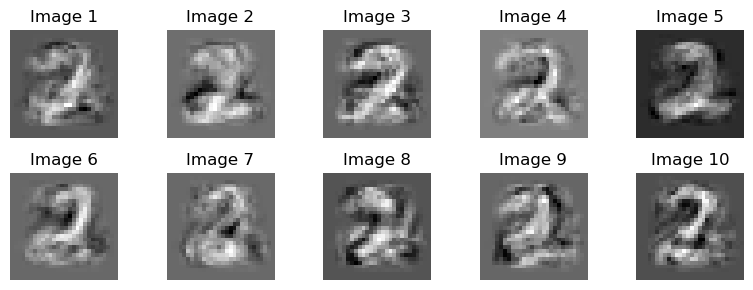

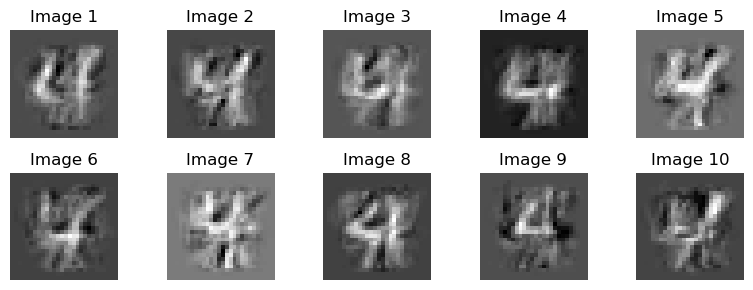

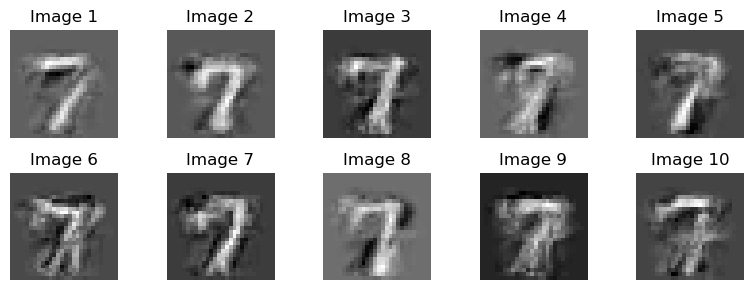

In [19]:
MLE_sampling(2)
MLE_sampling(4)
MLE_sampling(7 , zero_bias = 1)


- If the prior for $\mu$ is $\mathcal{N}(0 , \Sigma_k /N)$ $\implies$ $\mu_{map} = \frac{N_k \mu_k}{N_k + N}$ where $\mu_k$ is the sample mean of the images.



In [ ]:
# This Functions calculates the MLE estimates of mean and variance and the returns random samples from the generated distribution.
def MAP_sampling(k , num_samples = 900 , dim = 28*28 , N = 100):
    
    # Calculating the Sample Mean. 
    MLE_mean = np.zeros((dim , 1))
    for i in range(1 , num_samples + 1):
        path = 'MNIST_data/' + str(k) + '/' + str(i) + '.png'
        MLE_mean += mpimg.imread(path).reshape(-1,1) 

    MLE_mean = MLE_mean/num_samples

    # Calculating the Sample Variance.
    MLE_var = np.zeros((dim , dim))

    for i in range(1 , num_samples + 1):
        path = 'MNIST_data/' + str(k) + '/' + str(i) + '.png'
        img = mpimg.imread(path).reshape(-1,1)
        MLE_var += (img - MLE_mean)@((img - MLE_mean).T)

    MLE_var = MLE_var/(num_samples)


    
    # Sampling the images with multivariate gaussian with the calculated mean and variance.
    imgs = np.random.multivariate_normal(MLE_mean.reshape(784,) * num_samples/(num_samples + N) , MLE_var , 10) 

    # Plotting the images.
    fig, axes = plt.subplots(2,5, figsize=(8, 3))


    axes = axes.ravel()

    for i in range(len(imgs)):
        axes[i].imshow(imgs[i].reshape(28,28) , cmap = 'gray')
        axes[i].set_title(f"Image {i+1}")
        axes[i].axis("off")   

    plt.tight_layout()
    plt.show()
    
    return 

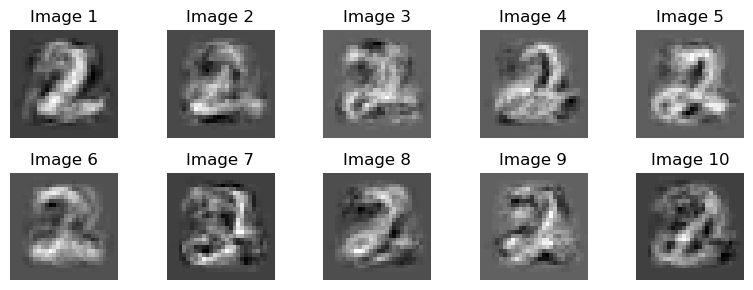

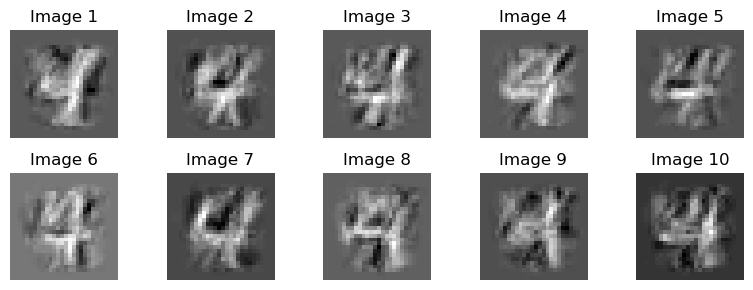

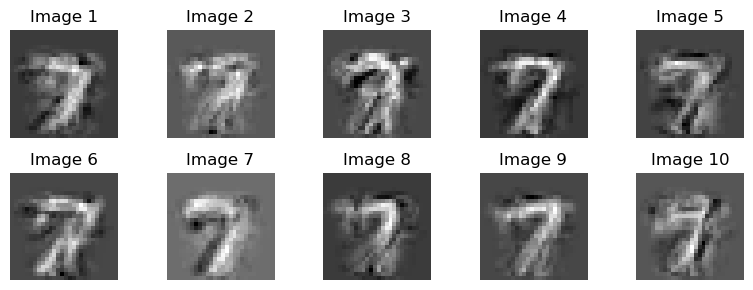

In [44]:
MAP_sampling(2)
MAP_sampling(4)
MAP_sampling(7)

- The MAP estimate gives more acceptable solutions due to the inclusion of the gaussian prior knowledge.

# Linear Regression

### Data Processing

In [128]:
# Seeding for reproducibilty.
np.random.seed(42)

# Loading the data.csv file into an array
data = np.genfromtxt('data.csv' , delimiter = ',',skip_header = 1)

data[:,0] = (data[:,0] - data[:,0].mean())/data[:,0].std()
data[:,1] = (data[:,1] - data[:,1].mean())/data[:,1].std()

# Preparing train and test sets.(in ratio 75:25)
np.random.shuffle(data)
X_train = data[:300,0].reshape(-1,1)
y_train = data[:300,1].reshape(-1,1)
X_test = data[300: , 0].reshape(-1,1)
y_test = data[300: , 1].reshape(-1,1)



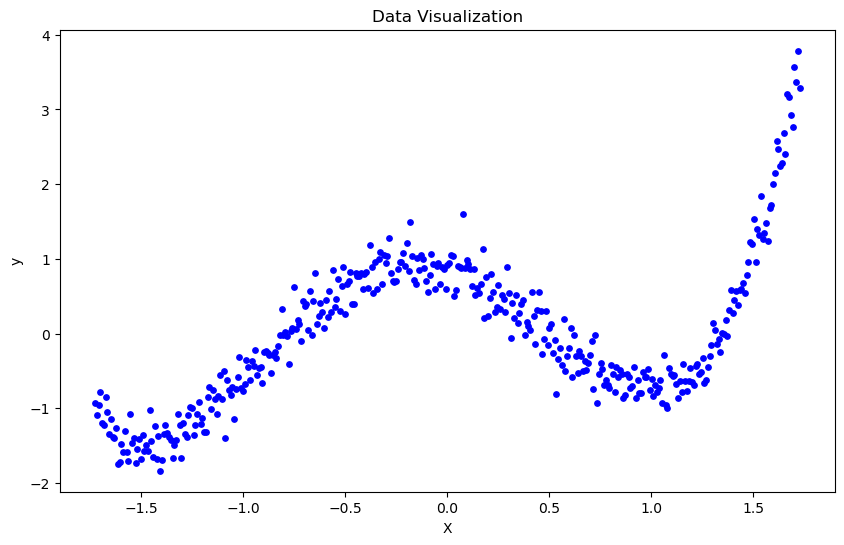

In [129]:
# Plotting the given data.
plt.figure(figsize = (10,6))
plt.scatter(data[:,0] , data[:,1] , s = 15 , c = 'blue')
plt.title("Data Visualization")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

### Training the weights using Gradient Descent

In [130]:
# A function that takes the training data and the hyperparameters like degree of the regression , number of epochs , learning rate ---> returns weights and the training loss after each epoch.
def polynomial_regression_grad_descent(degree , X_train , y_train, X_test , y_test , num_epochs , learning_rate ):

    loss = [] # A list to training loss at each epoch.
    

    # defining the Design Matrix (phi_matrix).
    phi_matrix = np.zeros(shape = (X_train.shape[0] , degree+1))

    for i in range(degree + 1):
        phi_matrix[:,i] = X_train[:,0]**i


    # Initializing the weights using Standard Normal Distribution
    weights_gradient_descent = np.random.randn(degree + 1 , 1)

    # Defining the gradient vector.
    grad = 2 * (phi_matrix.T @ phi_matrix) @ weights_gradient_descent - 2 * (phi_matrix.T @ y_train)


    # Training the weights.
    for i in range(num_epochs):

        # Append the loss to the list.
        loss.append((y_train-phi_matrix@weights_gradient_descent).T @ (y_train - phi_matrix @ weights_gradient_descent))

        # Gradient Descent.
        weights_gradient_descent = weights_gradient_descent - grad * learning_rate

        # Calculation gradient for the next epoch.
        grad = 2* phi_matrix.T @ phi_matrix @ weights_gradient_descent - 2 * phi_matrix.T @ y_train


        

    # Plotting the training data along with predictions.(Gradient Descent)
    plt.figure(figsize = (12,6))
    plt.scatter(X_train , y_train , s = 15 , c = 'blue' , label = 'True Data')
    plt.scatter(X_train, phi_matrix @ weights_gradient_descent , s = 15 ,c = 'red' , label = 'Predicted y values')
    plt.title(f"Performance of model on training data for an {degree} degree polynomial regression (Gradient Descent)")
    plt.legend()
    plt.xlabel("X values")
    plt.ylabel("y values")
    plt.show()


    weights_normal_eqn = np.linalg.inv(phi_matrix.T @ phi_matrix) @ phi_matrix.T @ y_train

    # Plotting the training data along with predictions(Normal Equation)
    plt.figure(figsize = (12,6))
    plt.scatter(X_train , y_train , s = 15 , c = 'blue' , label = 'True Data')
    plt.scatter(X_train, phi_matrix @ weights_normal_eqn , s = 15 ,c = 'red' , label = 'Predicted y values')
    plt.title(f"Performance of model on training data for an {degree} degree polynomial regression (Normal Equation)")
    plt.legend()
    plt.xlabel("X values")
    plt.ylabel("y values")
    plt.show()

    # defining the Design Matrix (phi_matrix) for test data.
    phi_matrix = np.zeros(shape = (X_test.shape[0] , degree+1))

    for i in range(degree + 1):
        phi_matrix[:,i] = X_test[:,0]**i
    
    # Plotting the test data along with predictions.(Gradient Descent)
    plt.figure(figsize = (12,6))
    plt.scatter(X_test , y_test , s = 15 , c = 'blue' , label = 'True Data')
    plt.scatter(X_test, phi_matrix @ weights_gradient_descent , s = 15 ,c = 'red' , label = 'Predicted y values')
    plt.title(f"Performance of model on test data for an {degree} degree polynomial regression (Gradient Descent)")
    plt.legend()
    plt.xlabel("X values")
    plt.ylabel("y values")
    plt.show()

    # Plotting the test data along with predictions.(Normal Equation)
    plt.figure(figsize = (12,6))
    plt.scatter(X_test , y_test , s = 15 , c = 'blue' , label = 'True Data')
    plt.scatter(X_test, phi_matrix @ weights_normal_eqn , s = 15 ,c = 'red' , label = 'Predicted y values')
    plt.title(f"Performance of model on test data for an {degree} degree polynomial regression (Normal Equation)")
    plt.legend()
    plt.xlabel("X values")
    plt.ylabel("y values")
    plt.show()

    # Plot the training loss vs Epochs.
    plt.figure(figsize = (12,6))
    plt.title("Training Loss vs Epochs")
    plt.plot([i+1 for i in range(len(loss))] , np.array(loss).flatten())
    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")
    plt.grid()
    plt.show()

    # Calculating the test loss.
    test_loss = (y_test-phi_matrix@weights_gradient_descent).T @ (y_test - phi_matrix @ weights_gradient_descent)
    return weights_gradient_descent , weights_normal_eqn , loss , test_loss


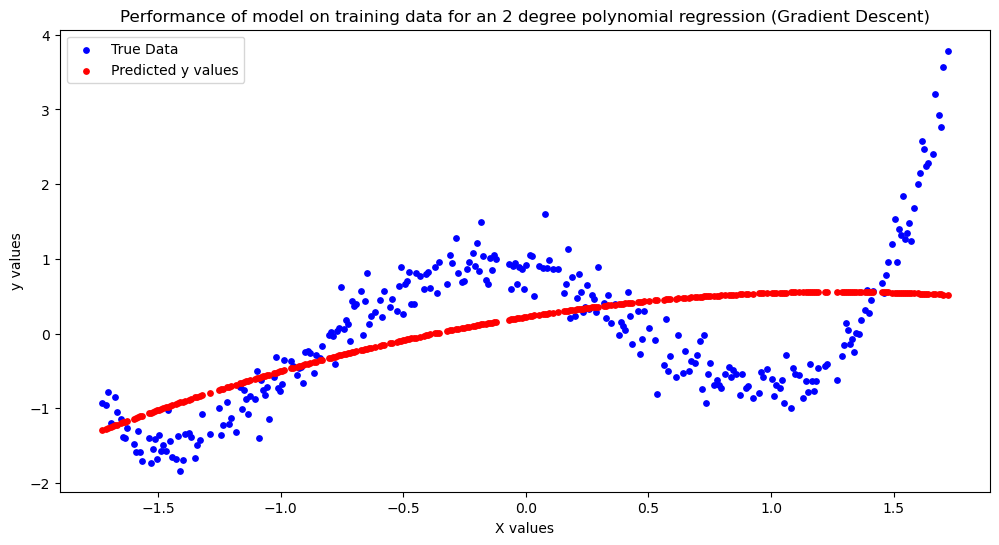

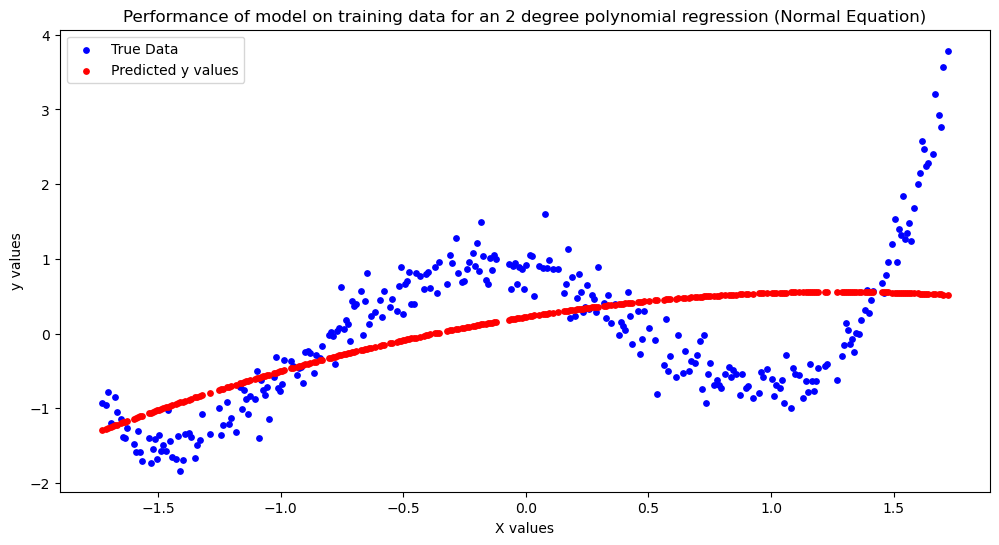

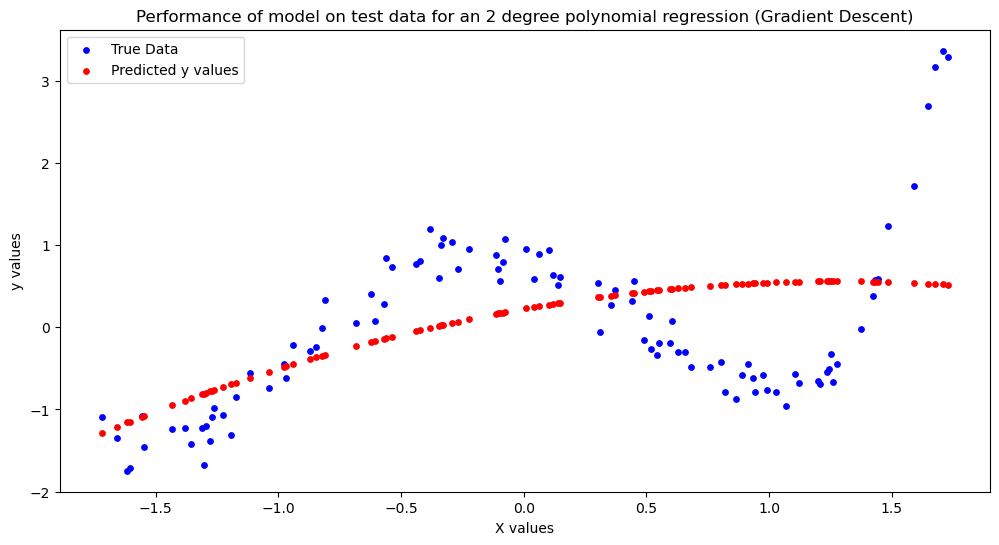

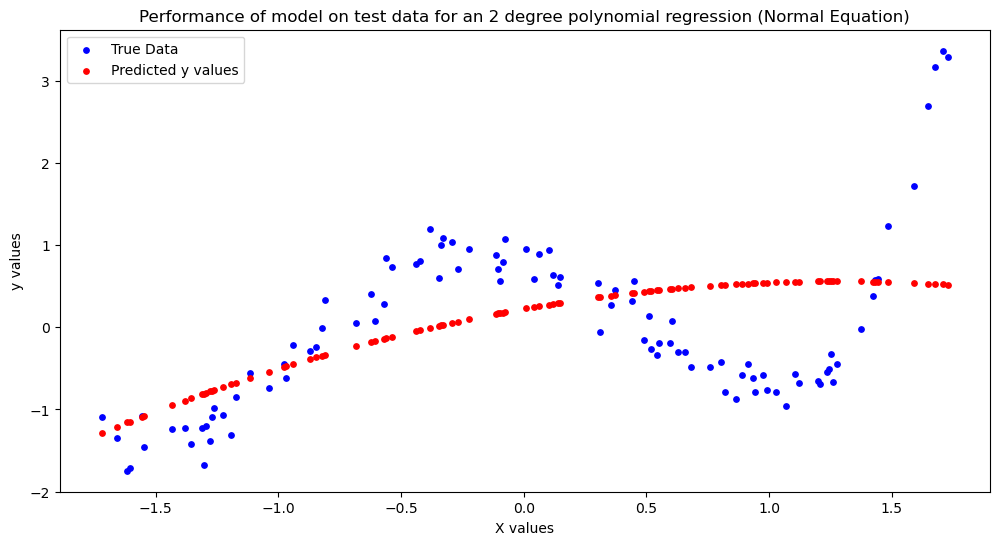

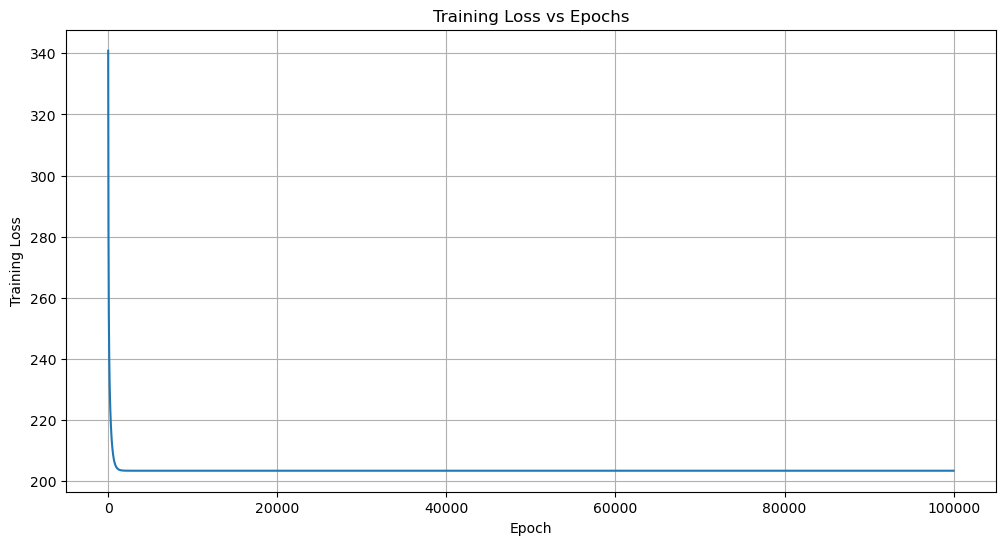

The corresponding weight vectors are:

Gradient Descent     Normal Equation     
0.2239               0.2239              
0.5242               0.5242              
-0.2052              -0.2052             


In [131]:
test_loss_array = np.zeros(5)
weights_gradient_descent, weights_normal_eqn,loss,test_loss = polynomial_regression_grad_descent(degree = 2 , X_train = X_train , y_train = y_train , X_test = X_test , y_test = y_test, num_epochs = 100000 , learning_rate = 1e-5 )
test_loss_array[0] = test_loss.item()
print("The corresponding weight vectors are:\n")
print("{:20} {:20}".format("Gradient Descent", "Normal Equation"))

    
for w_gd, w_ne in zip(weights_gradient_descent.flatten(), weights_normal_eqn.flatten()):
    print("{:<20.4f} {:<20.4f}".format(w_gd, w_ne))

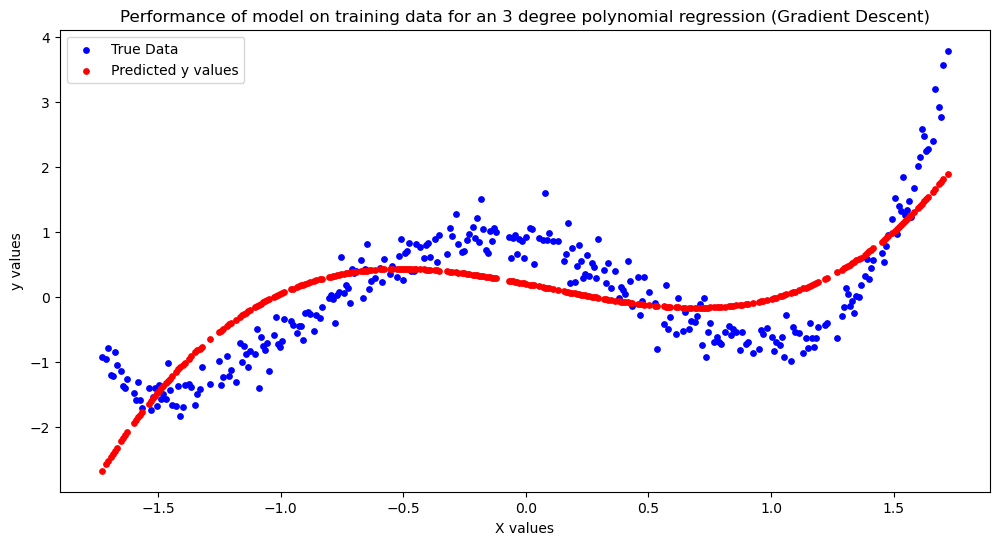

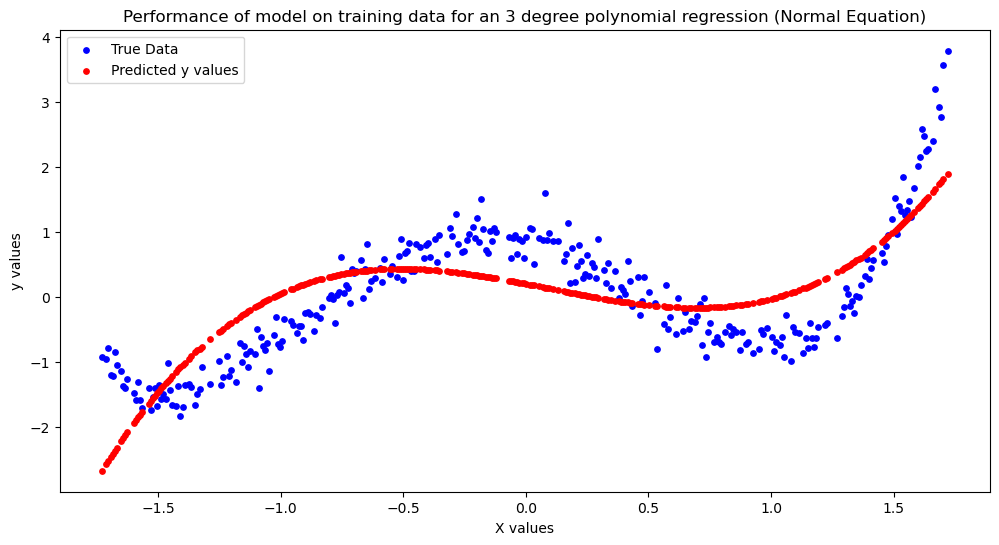

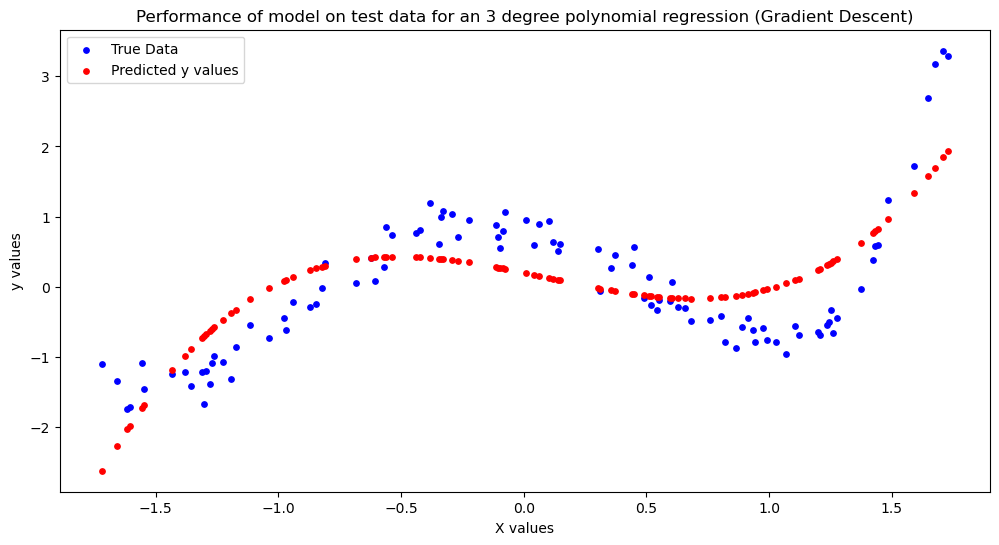

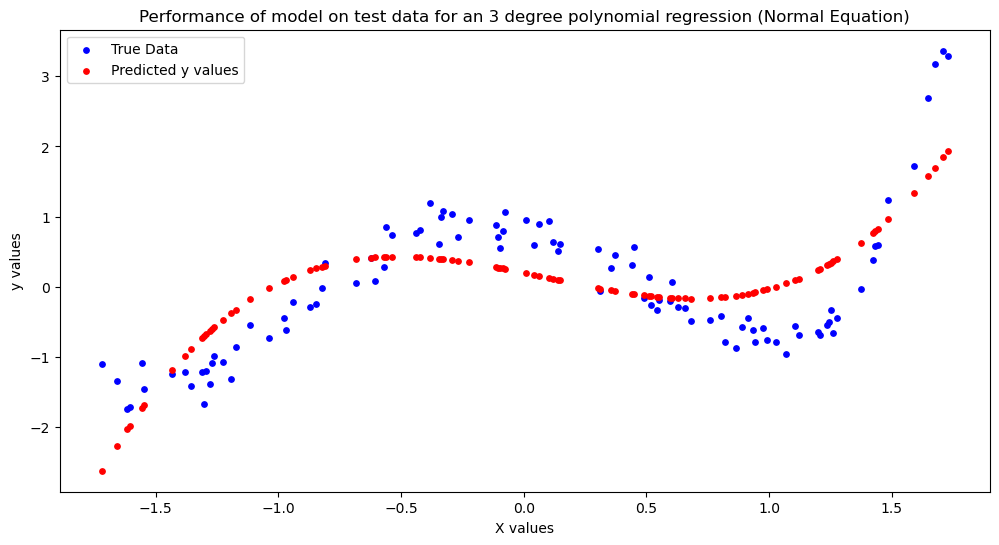

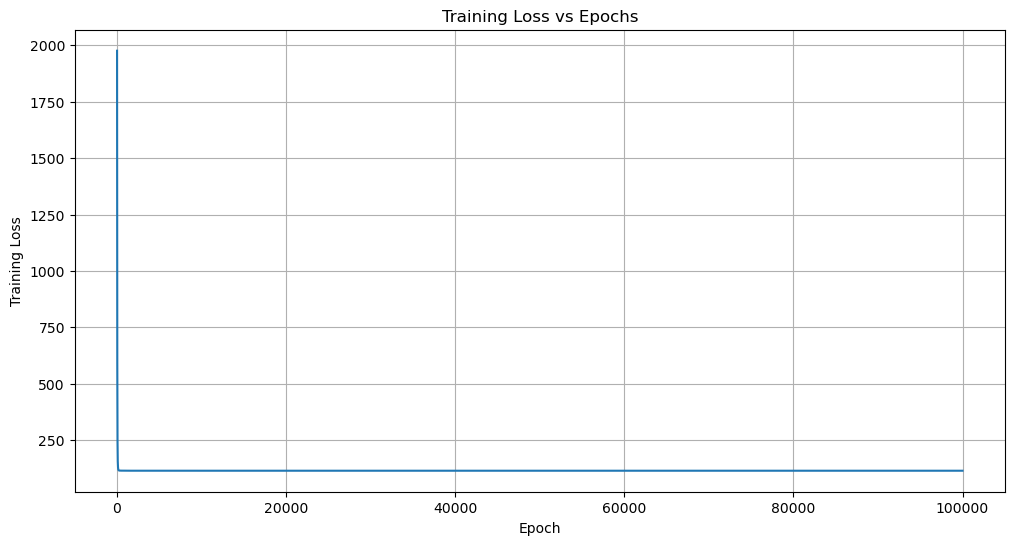

The corresponding weight vectors are:

Gradient Descent     Normal Equation     
0.1997               0.1997              
-0.7307              -0.7307             
-0.1913              -0.1913             
0.6916               0.6916              


In [132]:
weights_gradient_descent, weights_normal_eqn,loss,test_loss = polynomial_regression_grad_descent(degree = 3 , X_train = X_train , y_train = y_train , X_test = X_test , y_test = y_test, num_epochs = 100000 , learning_rate = 1e-5 )
test_loss_array[1] = test_loss.item()
print("The corresponding weight vectors are:\n")
print("{:20} {:20}".format("Gradient Descent", "Normal Equation"))


for w_gd, w_ne in zip(weights_gradient_descent.flatten(), weights_normal_eqn.flatten()):
    print("{:<20.4f} {:<20.4f}".format(w_gd, w_ne))

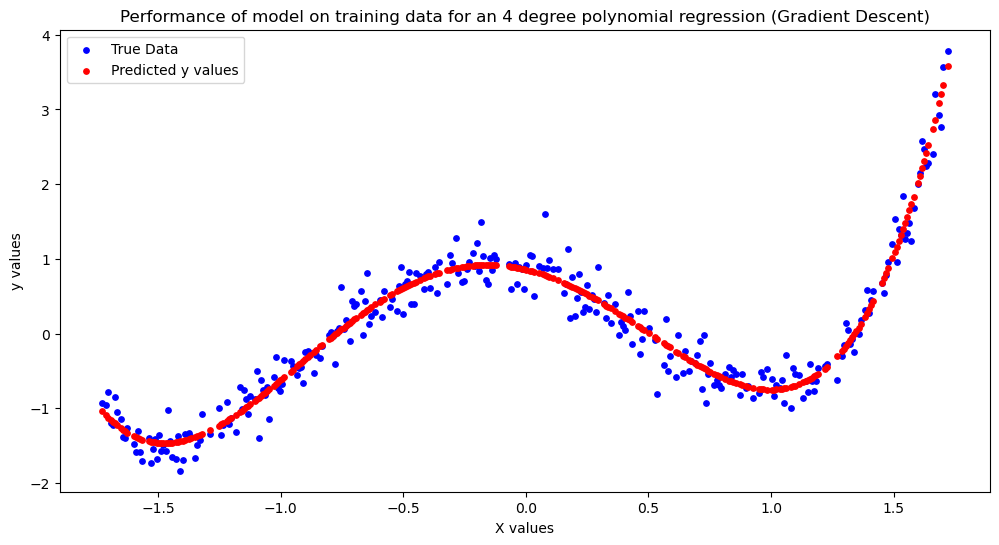

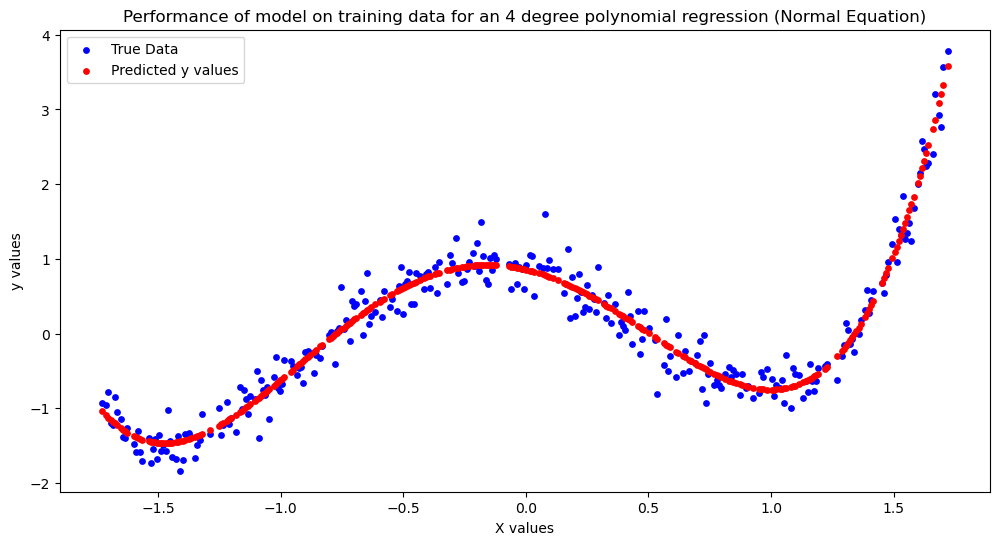

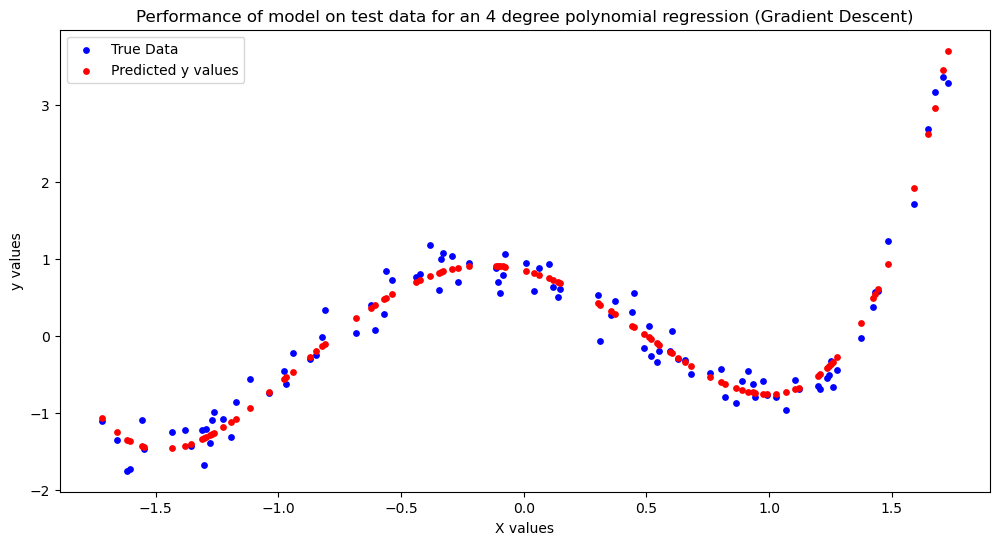

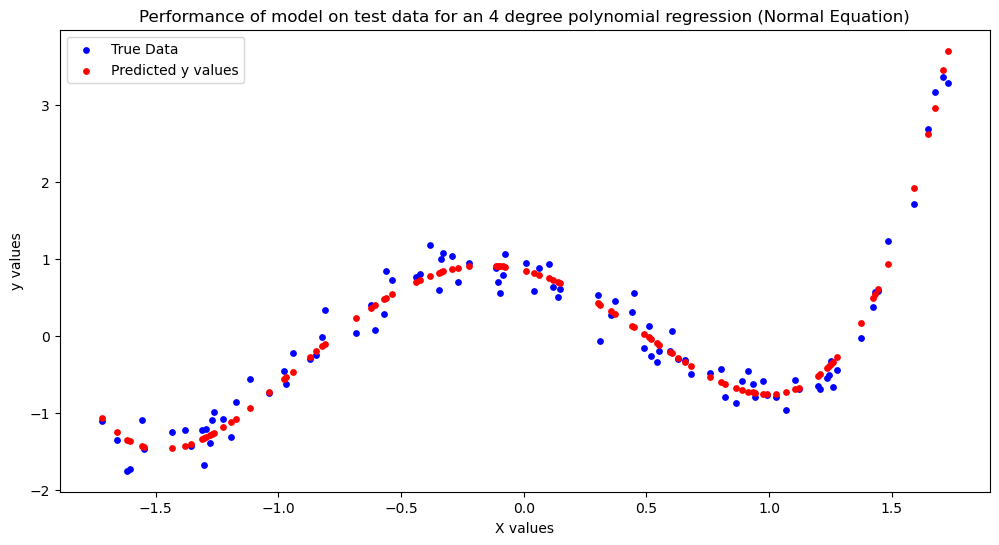

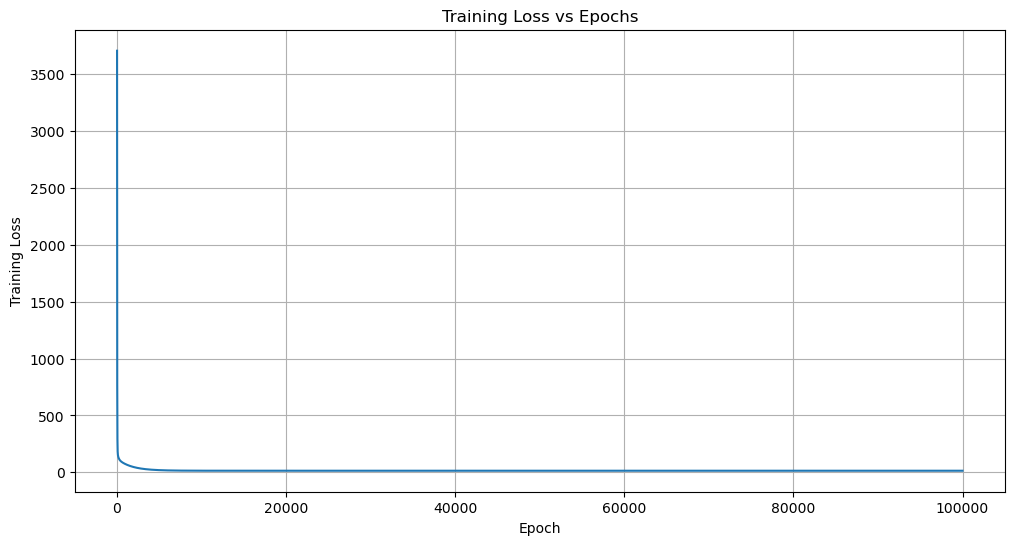

The corresponding weight vectors are:

Gradient Descent     Normal Equation     
0.8570               0.8570              
-0.7871              -0.7871             
-2.4016              -2.4016             
0.7234               0.7234              
0.8583               0.8583              


In [133]:
weights_gradient_descent, weights_normal_eqn,loss,test_loss = polynomial_regression_grad_descent(degree = 4 , X_train = X_train , y_train = y_train , X_test = X_test , y_test = y_test, num_epochs = 100000 , learning_rate = 1e-5 )
test_loss_array[2] = test_loss.item()
print("The corresponding weight vectors are:\n")
print("{:20} {:20}".format("Gradient Descent", "Normal Equation"))


for w_gd, w_ne in zip(weights_gradient_descent.flatten(), weights_normal_eqn.flatten()):
    print("{:<20.4f} {:<20.4f}".format(w_gd, w_ne))

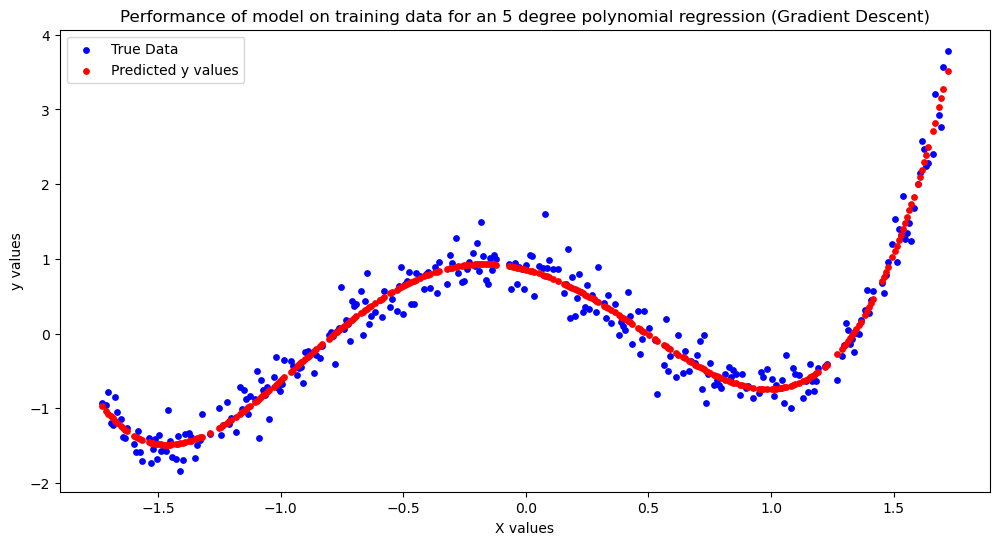

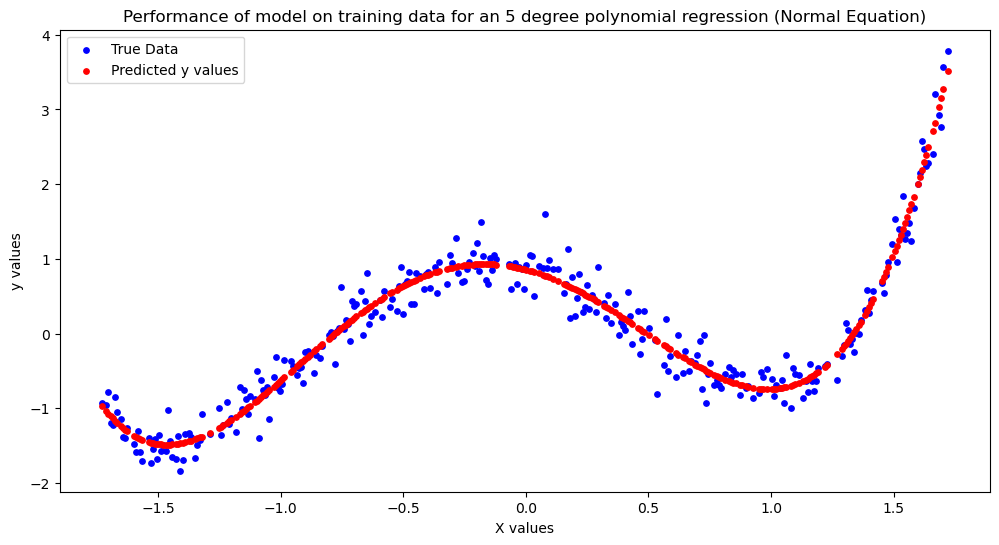

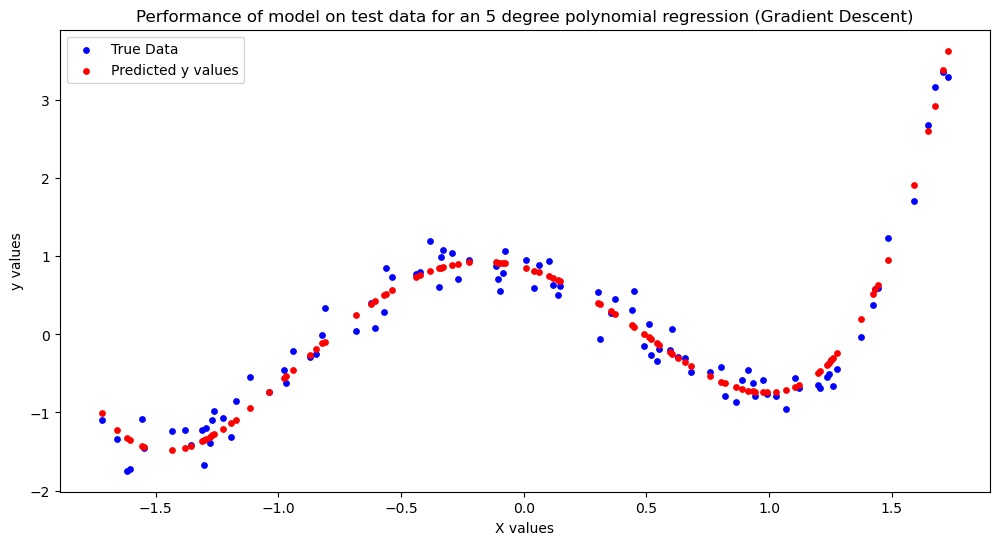

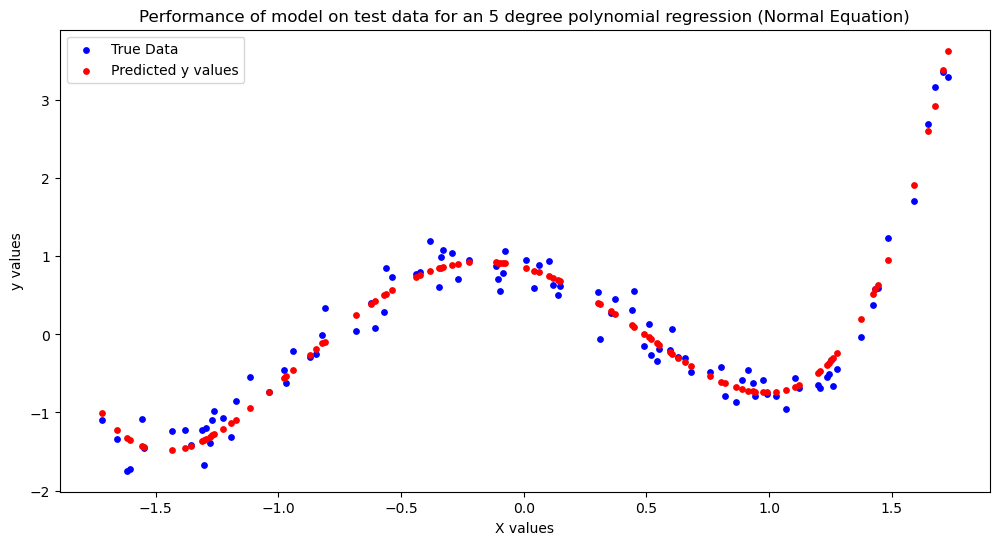

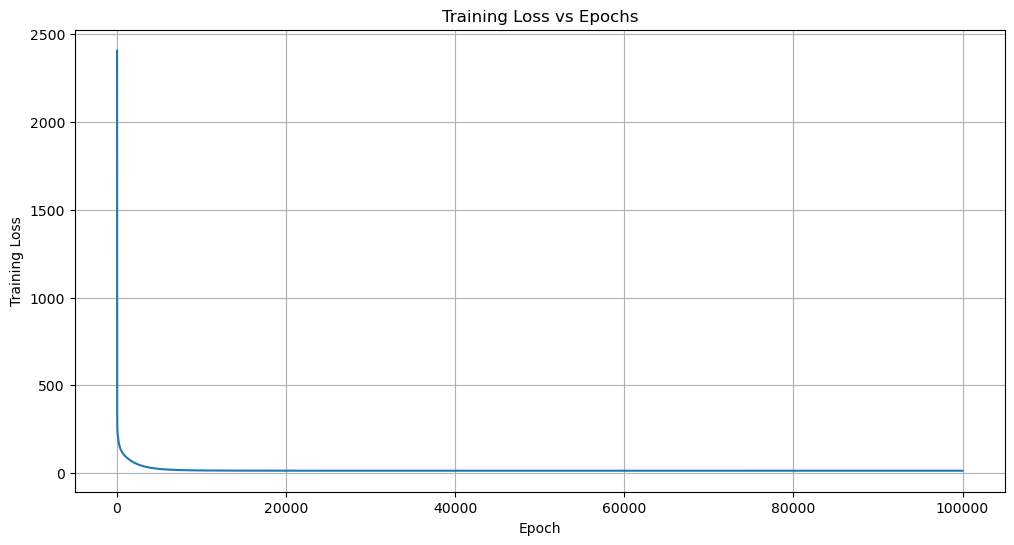

The corresponding weight vectors are:

Gradient Descent     Normal Equation     
0.8564               0.8564              
-0.8628              -0.8628             
-2.3997              -2.3997             
0.8425               0.8425              
0.8574               0.8574              
-0.0359              -0.0359             


In [134]:
weights_gradient_descent, weights_normal_eqn,loss,test_loss = polynomial_regression_grad_descent(degree = 5 , X_train = X_train , y_train = y_train , X_test = X_test , y_test = y_test, num_epochs = 100000 , learning_rate = 1e-5 )
test_loss_array[3] = test_loss.item()
print("The corresponding weight vectors are:\n")
print("{:20} {:20}".format("Gradient Descent", "Normal Equation"))


for w_gd, w_ne in zip(weights_gradient_descent.flatten(), weights_normal_eqn.flatten()):
    print("{:<20.4f} {:<20.4f}".format(w_gd, w_ne))

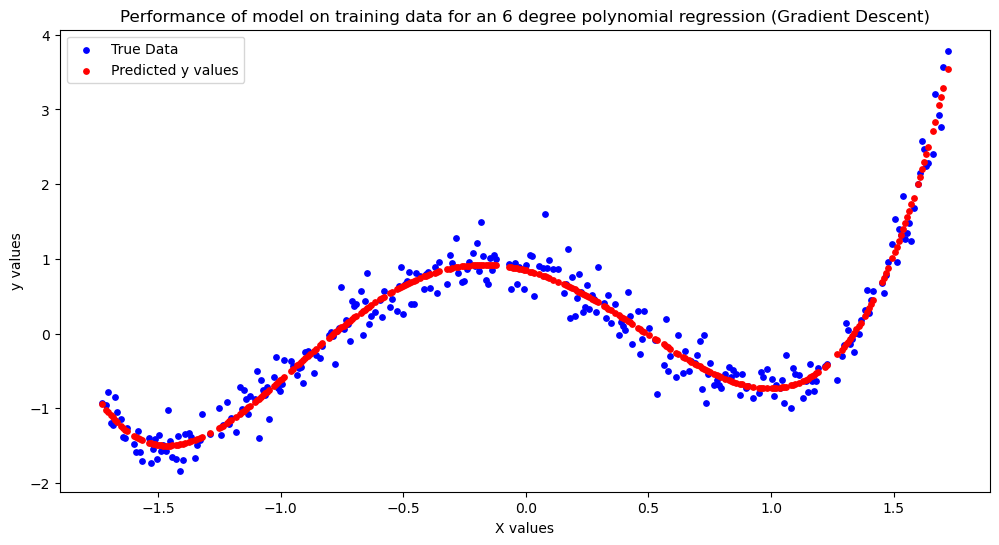

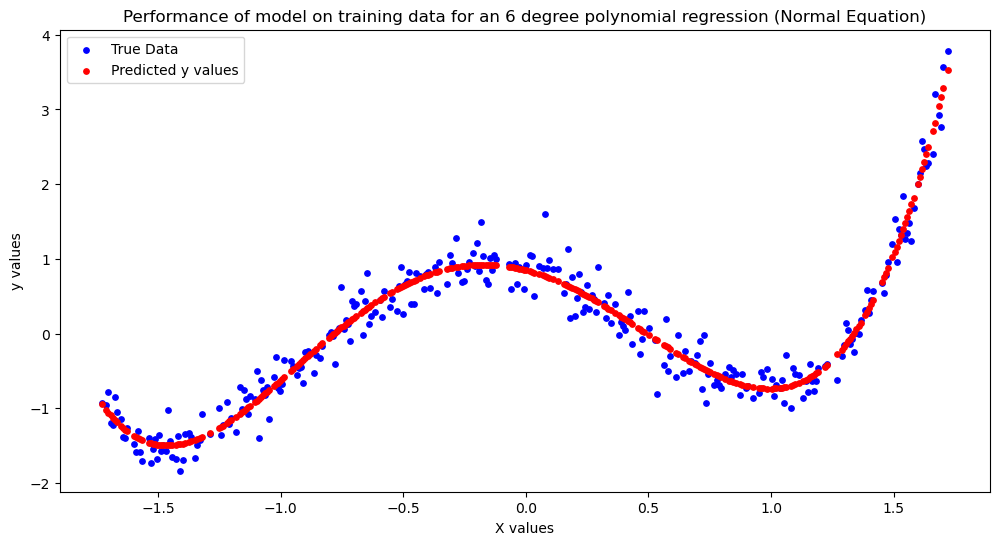

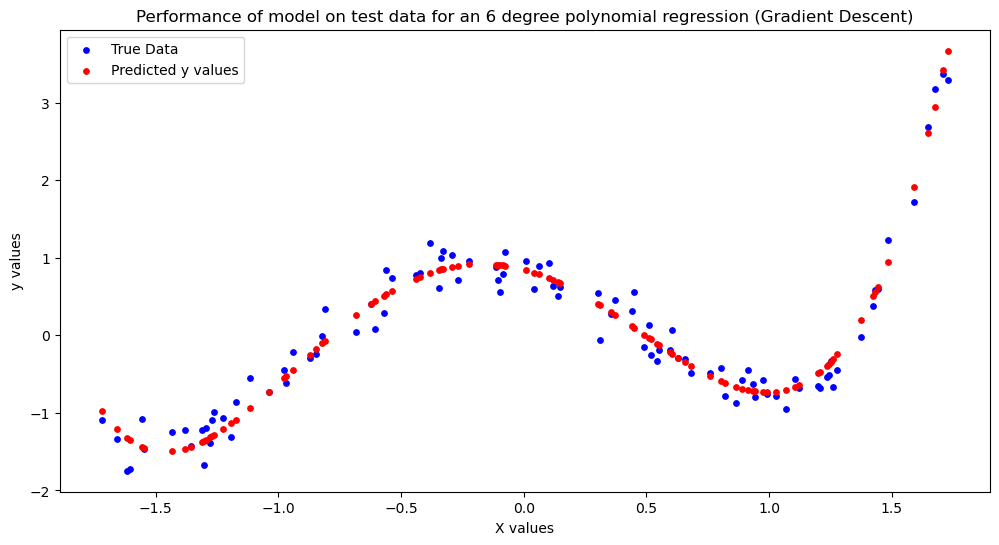

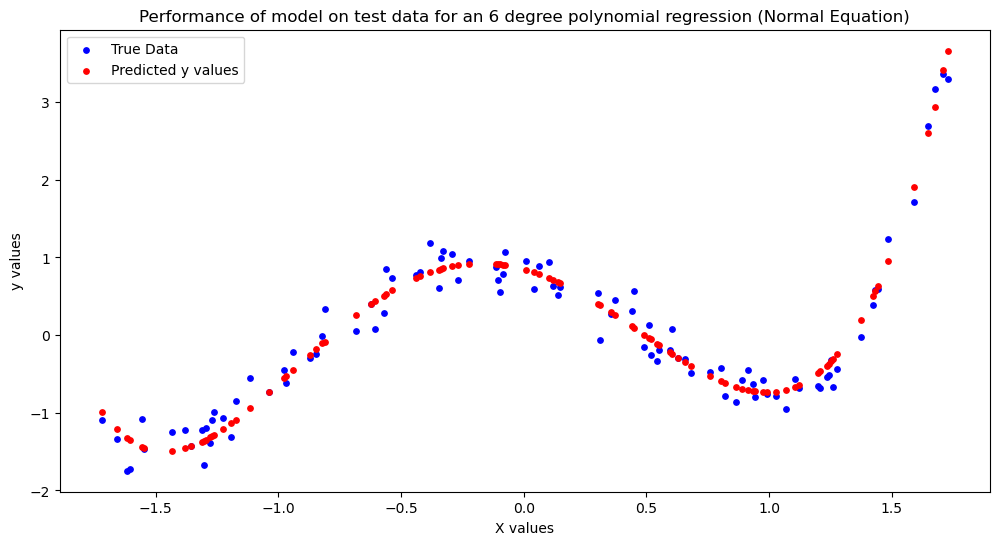

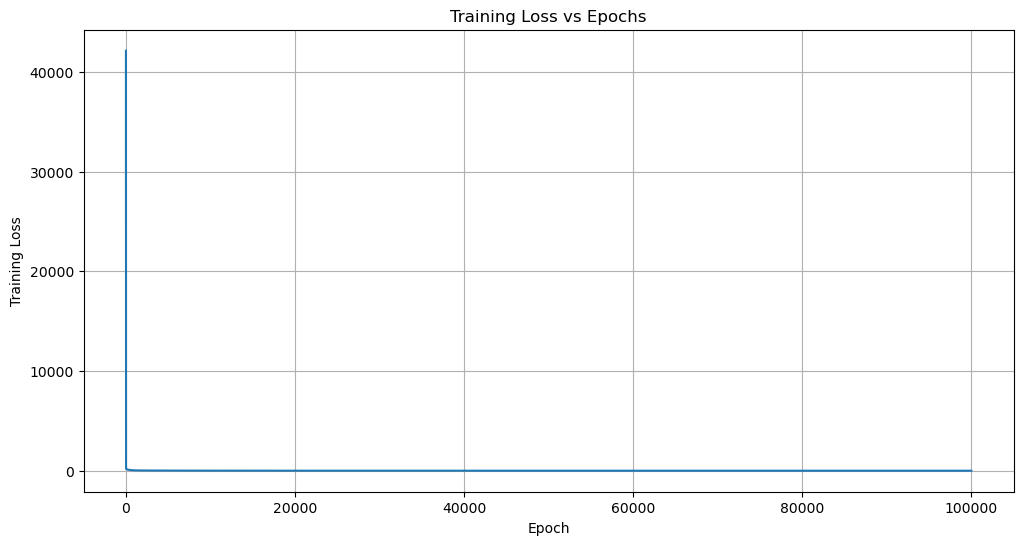

The corresponding weight vectors are:

Gradient Descent     Normal Equation     
0.8451               0.8489              
-0.8606              -0.8613             
-2.3250              -2.3469             
0.8396               0.8406              
0.7841               0.8041              
-0.0350              -0.0353             
0.0178               0.0131              


In [135]:
weights_gradient_descent, weights_normal_eqn,loss,test_loss = polynomial_regression_grad_descent(degree = 6 , X_train = X_train , y_train = y_train , X_test = X_test , y_test = y_test, num_epochs = 100000 , learning_rate = 1e-5 )
test_loss_array[4] = test_loss.item()
print("The corresponding weight vectors are:\n")
print("{:20} {:20}".format("Gradient Descent", "Normal Equation"))


for w_gd, w_ne in zip(weights_gradient_descent.flatten(), weights_normal_eqn.flatten()):
    print("{:<20.4f} {:<20.4f}".format(w_gd, w_ne))

- The Loss we took is a convex function. This means that the batch gradient descent always converges to its global minima (the weights generated by normal equation) for sufficiently large number of epochs.
- This can be verified by comparig the weights seen above.

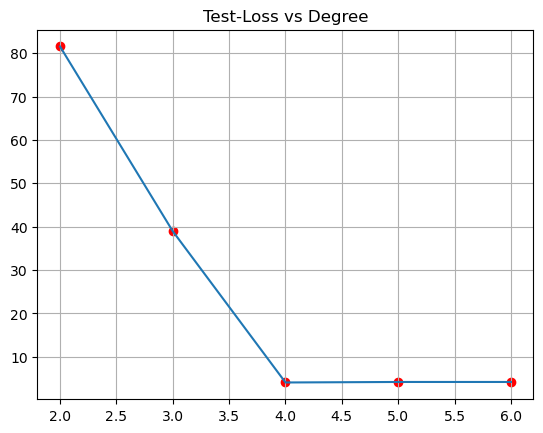

In [136]:
plt.title("Test-Loss vs Degree")
plt.plot([i for i in range(2,7)] , test_loss_array.reshape(5,1))
plt.scatter([i for i in range(2,7)] , test_loss_array.reshape(5,1) , c = 'red')
plt.grid()
plt.show()

- As we can see the test loss is decreasing as the degree of the polynomial is increasing
- For polynomials with degree 2 and 3 the test loss is very high indicating underfitting.
- Also for degree 5 polynomial, the 5th degree cofficient is very low and for the 6th degree polynomial the 5th and 6th degree coefficients are very low.
- Hence we can conclude that 4th degree polynomial makes the best fit to the given data.